# TP3 — Clustering

## Introduction

Dans ce TP, nous étudions différentes méthodes de **classification non supervisée (clustering)** afin de regrouper des données en fonction de leurs similarités.

L’objectif est de comparer deux grandes familles de méthodes :
- les méthodes de **partitionnement** (KMeans) ;
- les méthodes **hiérarchiques** (AgglomerativeClustering).

Ces méthodes sont appliquées à différents jeux de données, notamment un jeu de données de **villes caractérisées par leurs températures mensuelles**, ainsi que d’autres jeux de données réels.

Afin d’évaluer la qualité des partitions obtenues, nous utilisons l’**indice de silhouette**, qui permet de mesurer la cohésion et la séparation des clusters.

Enfin, une approche **hybride** combinant les deux types de méthodes est proposée et analysée.

In [1]:
import numpy as np
np.set_printoptions(threshold=10000,suppress=True)
import pandas as pd
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

## Question 1 — Application de KMeans pour obtenir 3 clusters

Dans cette question, on applique la méthode de partitionnement **KMeans** sur le jeu de données `villes.csv` afin d’obtenir **3 clusters**.

Les données sont d’abord normalisées, puis projetées dans le **plan principal** à l’aide d’une ACP (PCA) pour permettre une visualisation graphique.  
Enfin, les villes sont affichées dans ce plan avec une **couleur différente selon leur cluster**.

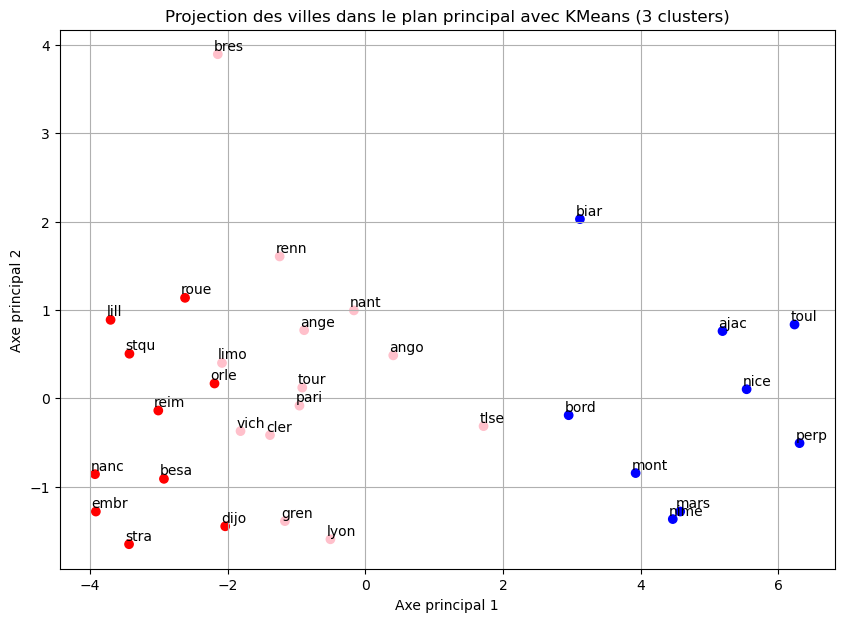

   Ville  Cluster
27  stra        0
3   besa        0
26  stqu        0
25  roue        0
23  reim        0
8   dijo        0
9   embr        0
20  orle        0
11  lill        0
16  nanc        0
0   ajac        1
28  toul        1
22  perp        1
19  nime        1
18  nice        1
15  mont        1
14  mars        1
5   bord        1
4   biar        1
17  nant        2
13  lyon        2
12  limo        2
10  gren        2
21  pari        2
7   cler        2
6   bres        2
24  renn        2
2   ango        2
1   ange        2
29  tlse        2
30  tour        2
31  vich        2


In [2]:
# Import des librairies nécessaires
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import matplotlib

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Ignorer les warnings (optionnel mais plus propre)
warnings.filterwarnings('ignore')

# Affichage complet des tableaux numpy
np.set_printoptions(threshold=10000, suppress=True)


# ===============================
# 1. Chargement du jeu de données
# ===============================

# Lecture du fichier CSV (séparateur = ';')
df = pd.read_csv("villes.csv", sep=";")


# ===============================
# 2. Séparation des données
# ===============================

# labels = noms des villes (1ère colonne)
labels = df.iloc[:, 0]

# X = variables numériques (températures mensuelles)
X = df.iloc[:, 1:]


# ===============================
# 3. Normalisation des données
# ===============================

# Standardisation (moyenne = 0, variance = 1)
# Important pour les algorithmes basés sur la distance (comme KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ===============================
# 4. Réduction de dimension (ACP)
# ===============================

# Projection des données en 2 dimensions pour visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


# ===============================
# 5. Application de KMeans
# ===============================

# Création du modèle avec 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)

# Attribution de chaque ville à un cluster
clustering = kmeans.fit_predict(X_scaled)


# ===============================
# 6. Visualisation des résultats
# ===============================

# Définition des couleurs pour les clusters
colors = ['red', 'yellow', 'blue', 'pink']

# Création du graphique
plt.figure(figsize=(10, 7))

# Affichage des points (villes)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clustering,
            cmap=matplotlib.colors.ListedColormap(colors))

# Ajout des noms des villes sur le graphique
for label, x, y in zip(labels, X_pca[:, 0], X_pca[:, 1]):
    plt.annotate(label, xy=(x, y), xytext=(-3, 3), textcoords='offset points')

# Ajout des titres et axes
plt.title("Projection des villes dans le plan principal avec KMeans (3 clusters)")
plt.xlabel("Axe principal 1")
plt.ylabel("Axe principal 2")

# Grille pour une meilleure lecture
plt.grid(True)

# Affichage du graphique
plt.show()


# ===============================
# 7. Affichage des résultats
# ===============================

# Création d'un tableau associant chaque ville à son cluster
resultat = pd.DataFrame({
    "Ville": labels,
    "Cluster": clustering
})

# Affichage trié par cluster
print(resultat.sort_values(by="Cluster"))

### Interprétation

La méthode KMeans a permis de partitionner les villes en 3 clusters distincts. Après normalisation des variables, une Analyse en Composantes Principales (ACP) a été appliquée afin de projeter les données dans un espace bidimensionnel, facilitant ainsi leur visualisation.

Le nuage de points obtenu met en évidence une structuration claire des données : les villes se regroupent en ensembles bien séparés, ce qui traduit l’existence de similarités significatives entre elles.

Plus précisément, on observe :

Un premier cluster regroupant principalement des villes du sud de la France (comme Nice, Marseille ou Montpellier), caractérisées par des températures plus élevées et un climat méditerranéen.
Un second cluster composé de villes du nord et de l’est (comme Strasbourg, Lille ou Nancy), associées à des températures plus basses et un climat plus continental ou océanique.
Un troisième cluster rassemblant des villes dites intermédiaires (comme Paris, Nantes ou Lyon), présentant des caractéristiques climatiques plus modérées.

Cette structuration montre que l’algorithme KMeans a su capturer une organisation naturelle des données, en distinguant des groupes cohérents du point de vue climatique.

Toutefois, ce partitionnement en 3 clusters reste un choix imposé a priori. Il est donc pertinent de s’interroger sur son optimalité, ce qui sera analysé dans la suite à l’aide de l’indice de silhouette.

Ainsi, KMeans permet ici de révéler des structures globales pertinentes dans les données, tout en soulignant la nécessité de valider le nombre de clusters choisi.

## Question 2 — Application de AgglomerativeClustering avec différentes méthodes d’agrégation

Dans cette question, on applique la méthode **AgglomerativeClustering** sur le jeu de données `villes.csv` afin d’obtenir **3 clusters**.

Trois méthodes d’agrégation sont testées :
- `ward`
- `average`
- `single`

Pour chaque méthode, les villes sont projetées dans le **plan principal** à l’aide d’une ACP, puis représentées graphiquement avec une **couleur différente selon leur cluster**.

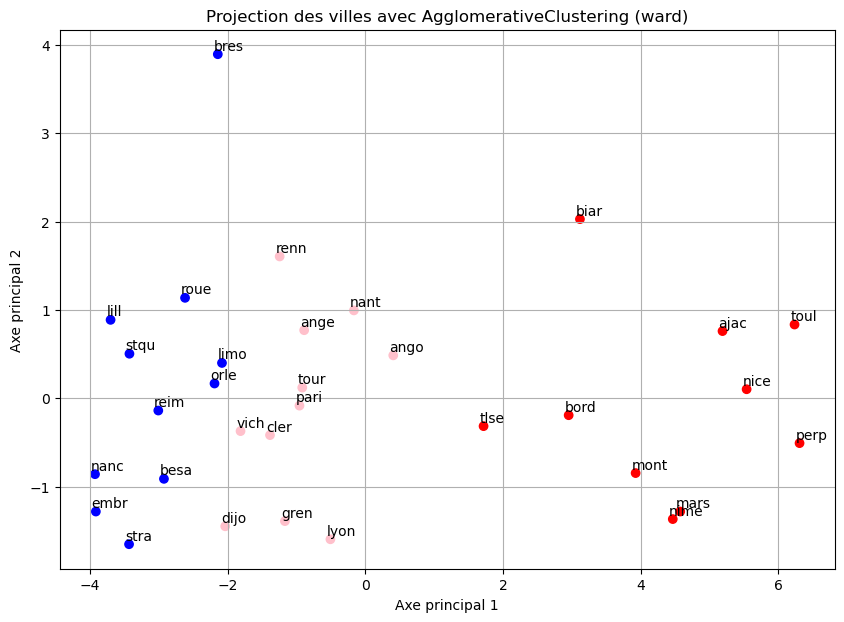


Résultats pour la méthode ward :
   Ville  Cluster
0   ajac        0
29  tlse        0
28  toul        0
22  perp        0
19  nime        0
18  nice        0
14  mars        0
15  mont        0
4   biar        0
5   bord        0
9   embr        1
11  lill        1
12  limo        1
6   bres        1
27  stra        1
16  nanc        1
26  stqu        1
25  roue        1
20  orle        1
3   besa        1
23  reim        1
1   ange        2
2   ango        2
24  renn        2
8   dijo        2
7   cler        2
17  nant        2
30  tour        2
13  lyon        2
10  gren        2
21  pari        2
31  vich        2


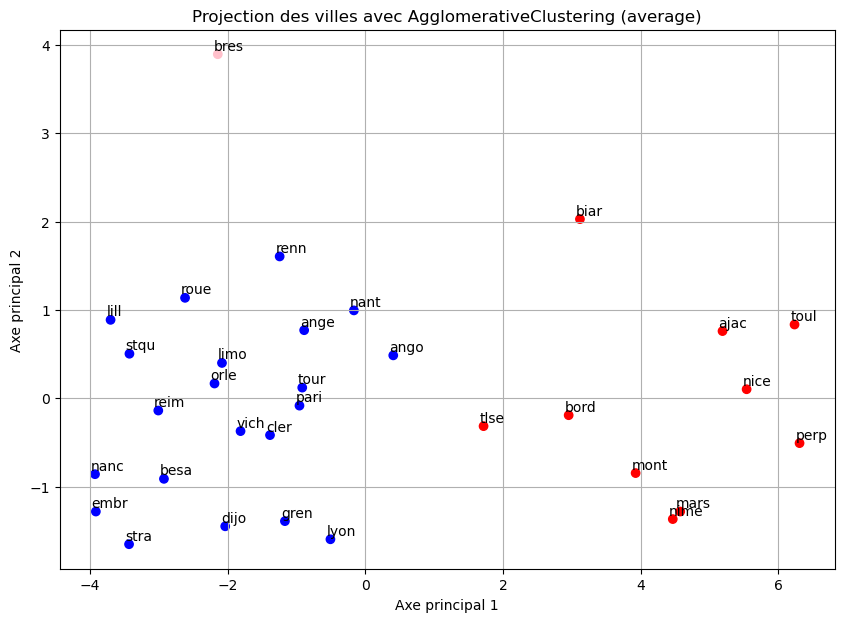


Résultats pour la méthode average :
   Ville  Cluster
0   ajac        0
29  tlse        0
28  toul        0
22  perp        0
19  nime        0
18  nice        0
14  mars        0
15  mont        0
4   biar        0
5   bord        0
1   ange        1
2   ango        1
27  stra        1
26  stqu        1
25  roue        1
24  renn        1
23  reim        1
3   besa        1
21  pari        1
20  orle        1
8   dijo        1
17  nant        1
16  nanc        1
30  tour        1
13  lyon        1
12  limo        1
11  lill        1
10  gren        1
9   embr        1
7   cler        1
31  vich        1
6   bres        2


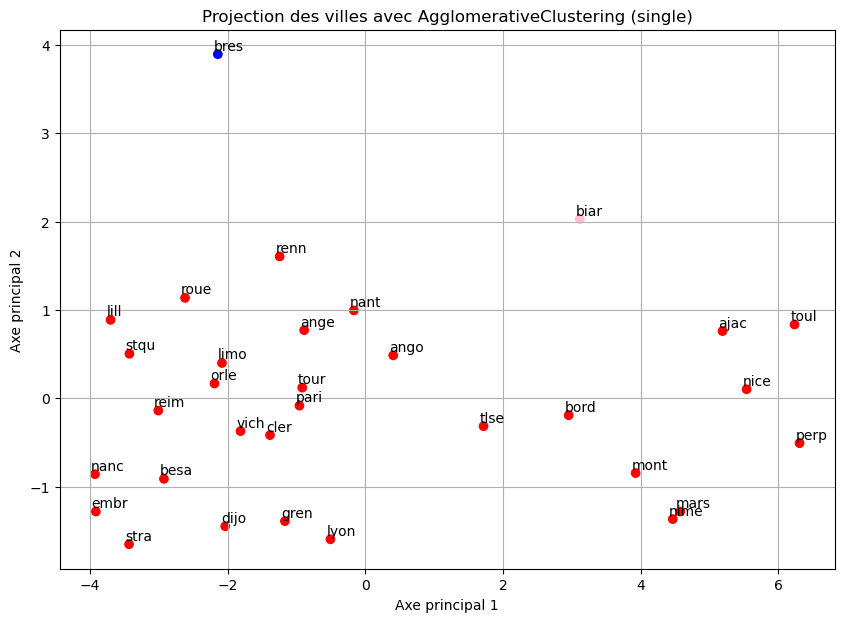


Résultats pour la méthode single :
   Ville  Cluster
0   ajac        0
29  tlse        0
28  toul        0
27  stra        0
26  stqu        0
25  roue        0
24  renn        0
23  reim        0
22  perp        0
21  pari        0
20  orle        0
19  nime        0
18  nice        0
17  nant        0
16  nanc        0
15  mont        0
14  mars        0
13  lyon        0
12  limo        0
11  lill        0
10  gren        0
9   embr        0
8   dijo        0
7   cler        0
5   bord        0
3   besa        0
2   ango        0
1   ange        0
30  tour        0
31  vich        0
6   bres        1
4   biar        2


In [3]:
# Import de la méthode de classification hiérarchique
from sklearn.cluster import AgglomerativeClustering

# Définition des méthodes d’agrégation à tester
linkages = ['ward', 'average', 'single']

# Couleurs utilisées pour représenter les clusters
colors = ['red', 'yellow', 'blue', 'pink']

# Boucle sur chaque méthode d’agrégation
for linkage in linkages:
    
    # Création du modèle AgglomerativeClustering avec 3 clusters
    model = AgglomerativeClustering(n_clusters=3, linkage=linkage)
    
    # Attribution de chaque ville à un cluster
    clustering = model.fit_predict(X_scaled)
    
    # Création du graphique
    plt.figure(figsize=(10, 7))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clustering,
                cmap=matplotlib.colors.ListedColormap(colors))
    
    # Ajout du nom des villes sur le graphique
    for label, x, y in zip(labels, X_pca[:, 0], X_pca[:, 1]):
        plt.annotate(label, xy=(x, y), xytext=(-3, 3), textcoords='offset points')
    
    # Titre et axes
    plt.title(f"Projection des villes avec AgglomerativeClustering ({linkage})")
    plt.xlabel("Axe principal 1")
    plt.ylabel("Axe principal 2")
    plt.grid(True)
    plt.show()
    
    # Affichage du cluster de chaque ville
    resultat = pd.DataFrame({
        "Ville": labels,
        "Cluster": clustering
    })
    
    print(f"\nRésultats pour la méthode {linkage} :")
    print(resultat.sort_values(by="Cluster"))

### Interprétation

La méthode AgglomerativeClustering a été appliquée avec trois critères d’agrégation : ward, average et single, afin d’analyser l’influence de ces choix sur la structure des clusters.

Les résultats mettent clairement en évidence que le choix du critère d’agrégation a un impact majeur sur la qualité du partitionnement.

La méthode ward produit des clusters compacts, bien équilibrés et clairement séparés. Ce comportement s’explique par le fait que ward minimise l’inertie intra-cluster, favorisant ainsi des groupes homogènes. On observe visuellement une structuration cohérente des villes, ce qui traduit une bonne organisation des données.

La méthode average donne des résultats intermédiaires : les clusters restent globalement cohérents, mais la séparation entre les groupes est moins marquée que pour ward. Cela s’explique par le fait que cette méthode repose sur la distance moyenne entre les points, ce qui peut lisser les différences entre clusters.

En revanche, la méthode single produit un partitionnement de mauvaise qualité. La majorité des villes se retrouve regroupée dans un seul cluster, avec quelques points isolés. Ce phénomène, appelé chaining effect, est dû à l’utilisation de la distance minimale, qui relie progressivement les points les plus proches sans garantir une cohérence globale des groupes.

Par exemple, des villes aux caractéristiques climatiques très différentes, comme Nice (climat méditerranéen chaud) et Strasbourg (climat plus continental et froid), peuvent être regroupées dans un même cluster avec la méthode single, ce qui est peu pertinent d’un point de vue métier.

D’un point de vue global, la méthode ward apparaît comme la plus adaptée pour ce jeu de données, car elle permet de mettre en évidence des groupes de villes cohérents, probablement liés à des similarités climatiques (par exemple, distinction entre villes du sud, du nord et intermédiaires).

Enfin, cette analyse montre que les méthodes hiérarchiques sont fortement dépendantes du critère d’agrégation choisi, ce qui souligne l’importance de comparer plusieurs approches afin d’identifier la structure la plus pertinente des données.

## Question 3 — Détermination de la meilleure partition pour KMeans avec l’indice de Silhouette

Dans cette question, on cherche à déterminer le **meilleur nombre de clusters** pour la méthode **KMeans**.

Pour cela, on calcule l’**indice de silhouette** pour les partitions comportant :
- 2 clusters
- 3 clusters
- 4 clusters
- 5 clusters
- 6 clusters

La meilleure partition correspond à celle qui donne **l’indice de silhouette le plus élevé**.

Pour k = 2, le score de silhouette est : 0.6256
Pour k = 3, le score de silhouette est : 0.3741
Pour k = 4, le score de silhouette est : 0.3102
Pour k = 5, le score de silhouette est : 0.3015
Pour k = 6, le score de silhouette est : 0.3499

Meilleure partition pour KMeans :
Le meilleur nombre de clusters est k = 2
Le score de silhouette maximal est : 0.6256


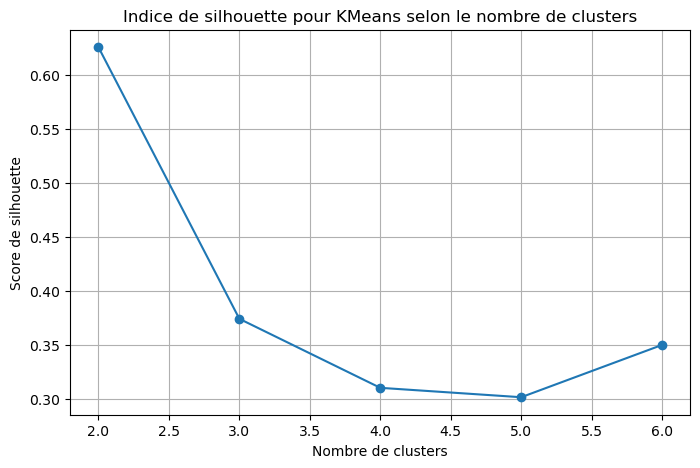

In [4]:
# Import du critère de silhouette
from sklearn.metrics import silhouette_score

# Liste pour stocker les scores de silhouette
scores = []

# Liste des nombres de clusters testés
k_values = range(2, 7)

# Boucle sur les partitions possibles : 2, 3, 4, 5 et 6 clusters
for k in k_values:
    
    # Création du modèle KMeans avec k clusters
    kmeans = KMeans(n_clusters=k, random_state=42)
    
    # Attribution de chaque ville à un cluster
    clustering = kmeans.fit_predict(X_scaled)
    
    # Calcul du score de silhouette
    score = silhouette_score(X_scaled, clustering)
    
    # Stockage du résultat
    scores.append(score)
    
    # Affichage du score obtenu
    print(f"Pour k = {k}, le score de silhouette est : {score:.4f}")

# Détermination du meilleur nombre de clusters
best_k = k_values[np.argmax(scores)]
best_score = max(scores)

print("\nMeilleure partition pour KMeans :")
print(f"Le meilleur nombre de clusters est k = {best_k}")
print(f"Le score de silhouette maximal est : {best_score:.4f}")

# Visualisation des scores de silhouette en fonction du nombre de clusters
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), scores, marker='o')
plt.title("Indice de silhouette pour KMeans selon le nombre de clusters")
plt.xlabel("Nombre de clusters")
plt.ylabel("Score de silhouette")
plt.grid(True)
plt.show()

### Interprétation

L’indice de silhouette a été calculé pour différentes partitions obtenues avec la méthode KMeans, en faisant varier le nombre de clusters de 2 à 6.

Les résultats montrent clairement que le score de silhouette est maximal pour k = 2 (≈ 0.6256), ce qui indique que cette partition offre la meilleure qualité de clustering.

En effet, l’indice de silhouette mesure à la fois la cohésion intra-cluster (proximité des points au sein d’un même groupe) et la séparation inter-clusters (distance entre les groupes). Un score élevé signifie que les individus sont bien assignés à leur cluster et que les clusters sont bien distincts.

On observe que lorsque le nombre de clusters augmente (k ≥ 3), le score diminue fortement, ce qui traduit une dégradation de la qualité du partitionnement. Cela signifie que l’algorithme fragmente artificiellement des groupes naturellement homogènes, réduisant ainsi la cohérence interne des clusters.

Par exemple, des villes ayant des caractéristiques climatiques proches (comme Paris, Nantes ou Lyon) peuvent être séparées dans différents clusters lorsque k augmente, ce qui diminue la pertinence du regroupement.

Le graphique du score de silhouette confirme cette observation : il présente un maximum net pour k = 2, suivi d’une baisse importante, ce qui indique que la structure naturelle des données semble être composée de deux grands groupes distincts.

D’un point de vue métier, cela peut correspondre à une séparation globale entre des villes à climat plus chaud (sud de la France) et des villes à climat plus froid (nord et est), ce qui donne du sens au clustering obtenu.

Enfin, il est intéressant de noter que ce résultat diffère du choix arbitraire de k = 3 effectué dans les questions précédentes, ce qui montre l’importance d’utiliser des critères objectifs comme l’indice de silhouette pour déterminer le nombre optimal de clusters.

On conclut donc que k = 2 est le nombre de clusters optimal pour KMeans sur ce jeu de données, car il maximise la qualité du partitionnement tout en respectant la structure naturelle des données.

## Question 4 — Détermination de la meilleure partition pour AgglomerativeClustering avec l’indice de Silhouette

Dans cette question, on cherche à déterminer le **meilleur nombre de clusters** pour la méthode **AgglomerativeClustering**.

Pour cela, on calcule l’**indice de silhouette** pour différentes partitions :
- de 2 à 6 clusters

et pour chaque méthode d’agrégation :
- `ward`
- `average`
- `single`

La meilleure partition correspond à celle qui donne **le score de silhouette maximal**.


===== Méthode : ward =====
k = 2, score = 0.6256
k = 3, score = 0.3681
k = 4, score = 0.3183
k = 5, score = 0.3327
k = 6, score = 0.3213
--> Meilleur k pour ward : 2 (score = 0.6256)


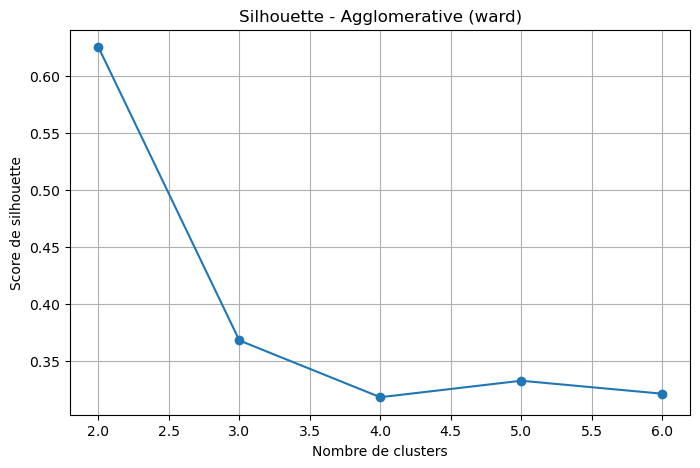


===== Méthode : average =====
k = 2, score = 0.6256
k = 3, score = 0.4957
k = 4, score = 0.4041
k = 5, score = 0.3394
k = 6, score = 0.3157
--> Meilleur k pour average : 2 (score = 0.6256)


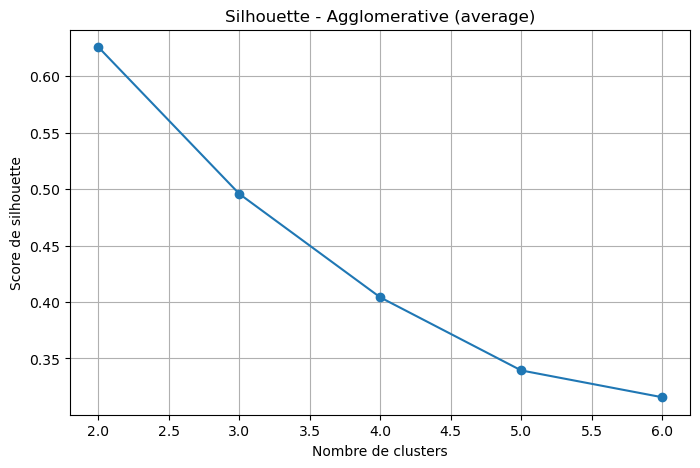


===== Méthode : single =====
k = 2, score = 0.1783
k = 3, score = -0.0344
k = 4, score = 0.1832
k = 5, score = 0.4054
k = 6, score = 0.3212
--> Meilleur k pour single : 5 (score = 0.4054)


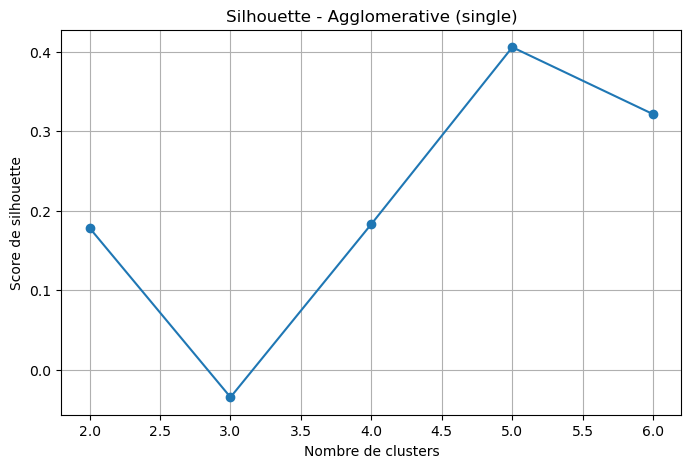


===== Meilleure partition globale =====
Méthode : ward
Nombre de clusters : 2
Score de silhouette : 0.6256


In [5]:
from sklearn.metrics import silhouette_score

# Méthodes d’agrégation
linkages = ['ward', 'average', 'single']

# Nombre de clusters à tester
k_values = range(2, 7)

# Dictionnaire pour stocker les résultats
results = {}

# Boucle sur chaque méthode d’agrégation
for linkage in linkages:
    
    print(f"\n===== Méthode : {linkage} =====")
    
    scores = []
    
    # Boucle sur les nombres de clusters
    for k in k_values:
        
        # Création du modèle
        model = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        
        # Clustering
        clustering = model.fit_predict(X_scaled)
        
        # Calcul du score de silhouette
        score = silhouette_score(X_scaled, clustering)
        
        scores.append(score)
        
        print(f"k = {k}, score = {score:.4f}")
    
    # Meilleur k pour cette méthode
    best_k = k_values[np.argmax(scores)]
    best_score = max(scores)
    
    print(f"--> Meilleur k pour {linkage} : {best_k} (score = {best_score:.4f})")
    
    # Stockage des résultats
    results[linkage] = (best_k, best_score)
    
    # Graphique
    plt.figure(figsize=(8, 5))
    plt.plot(list(k_values), scores, marker='o')
    plt.title(f"Silhouette - Agglomerative ({linkage})")
    plt.xlabel("Nombre de clusters")
    plt.ylabel("Score de silhouette")
    plt.grid(True)
    plt.show()


# ===============================
# Meilleure méthode globale
# ===============================

best_method = max(results, key=lambda x: results[x][1])
best_k_global, best_score_global = results[best_method]

print("\n===== Meilleure partition globale =====")
print(f"Méthode : {best_method}")
print(f"Nombre de clusters : {best_k_global}")
print(f"Score de silhouette : {best_score_global:.4f}")

### Interprétation

L’indice de silhouette a été calculé pour différentes partitions obtenues avec la méthode AgglomerativeClustering, en faisant varier le nombre de clusters de 2 à 6 et en testant trois critères d’agrégation : ward, average et single.

Les résultats mettent en évidence des différences significatives selon la méthode utilisée :

Pour les méthodes ward et average, le score de silhouette est maximal pour k = 2 (≈ 0.6256). Ce score élevé traduit une excellente qualité de clustering, caractérisée par une forte cohésion intra-cluster et une bonne séparation inter-clusters. Le fait que ces deux méthodes convergent vers le même résultat renforce la robustesse de cette partition.
En revanche, la méthode single donne des résultats nettement moins satisfaisants. Bien que le meilleur score soit obtenu pour k = 5 (≈ 0.4054), celui-ci reste significativement inférieur à celui obtenu avec ward et average. De plus, les variations importantes des scores (notamment un score négatif pour k = 3) indiquent une instabilité du clustering. Cela s’explique par le chaining effect, qui tend à créer des clusters étendus et peu homogènes.

L’analyse des courbes de silhouette confirme ces observations : pour ward et average, le maximum est atteint pour k = 2, puis les scores diminuent lorsque le nombre de clusters augmente, ce qui traduit une fragmentation progressive de groupes naturellement cohérents.

Ainsi, la meilleure partition globale est obtenue avec la méthode ward (ou average) pour k = 2, avec un score de silhouette maximal de 0.6256.

D’un point de vue métier, cette partition suggère que les villes peuvent être regroupées en deux grandes catégories climatiques, par exemple entre des villes à climat plus chaud (sud) et des villes à climat plus froid (nord et est).

Enfin, ce résultat est cohérent avec celui obtenu pour KMeans, qui identifie également k = 2 comme nombre optimal de clusters. Cette convergence entre méthodes différentes renforce la pertinence de cette structure et suggère qu’elle reflète une organisation naturelle des données.

On conclut donc que la partition en 2 clusters avec la méthode ward est la plus adaptée pour ce jeu de données, en raison de sa stabilité, de sa cohérence et de sa capacité à produire des groupes interprétables.

## Question 5 — Comparaison des méthodes pour 3 clusters

Pour répondre à cette question, nous comparons les scores de silhouette obtenus pour k = 3 clusters avec les différentes méthodes de clustering.

Les résultats obtenus sont les suivants :

KMeans : score ≈ 0.37
Agglomerative (ward) : score ≈ 0.37
Agglomerative (average) : score ≈ 0.50
Agglomerative (single) : score négatif (≈ -0.03)

On observe que la méthode AgglomerativeClustering avec le critère average donne le meilleur score de silhouette pour k = 3. Cela signifie que, pour ce nombre de clusters, elle produit des groupes à la fois plus homogènes et mieux séparés que les autres méthodes.

En revanche, la méthode single donne un score négatif, ce qui indique une très mauvaise qualité de clustering : certains points sont plus proches des clusters voisins que du leur. Ce comportement est caractéristique du chaining effect, qui rend cette méthode peu adaptée à ce jeu de données.

Les méthodes KMeans et Agglomerative (ward) donnent des résultats similaires, mais moins performants que la méthode average. Cela suggère qu’avec k = 3, ces méthodes ont tendance à mal séparer certains groupes ou à fragmenter des clusters naturels.

Toutefois, il est important de replacer ce résultat dans un contexte global. En effet, les questions précédentes ont montré que le nombre optimal de clusters est k = 2, avec un score de silhouette nettement supérieur (≈ 0.62). Ainsi, même si la méthode average est la meilleure pour k = 3, cette partition reste globalement moins pertinente que celle obtenue avec k = 2.

D’un point de vue métier, cela signifie que forcer une partition en 3 groupes introduit une complexité artificielle dans les données, en séparant des villes qui partagent des caractéristiques similaires.

On conclut donc que :

pour k = 3, la meilleure méthode est AgglomerativeClustering (average) ;
mais de manière globale, la structure la plus pertinente reste une partition en 2 clusters, indépendamment de la méthode utilisée.

## Question 6 : Avantages et inconvénients des méthodes de clustering

### Méthodes de partitionnement (KMeans)

### Avantages

- **Simple à comprendre et facile à implémenter** : l’algorithme repose sur un principe intuitif de minimisation de la distance aux centroïdes.  

- **Rapide et efficace**, même sur de grands jeux de données : il est particulièrement adapté aux bases volumineuses (par exemple, segmentation de millions de clients en marketing).  

- **Bonne performance lorsque les clusters sont bien séparés et de forme sphérique** : dans notre TP, KMeans permet d’identifier des groupes cohérents de villes en fonction de leurs caractéristiques climatiques.  


### Inconvénients

- **Nécessite de fixer le nombre de clusters (k) à l’avance** : ce choix peut être arbitraire. Dans notre cas, k = 3 a été imposé initialement, alors que l’indice de silhouette a montré que **k = 2** était plus pertinent.  

- **Sensible à l’initialisation des centres** : différentes initialisations peuvent conduire à des résultats différents.  

- **Sensible aux valeurs aberrantes (outliers)** : un point extrême peut influencer fortement la position des centroïdes.  

- **Suppose des clusters de forme simple (sphériques et de taille similaire)** : ce qui peut être limitant si les données ont une structure complexe.  



### Méthodes hiérarchiques (AgglomerativeClustering)

### Avantages

- **Ne nécessite pas de fixer le nombre de clusters au départ** : on peut explorer plusieurs partitions en coupant le dendrogramme à différents niveaux.  

- **Permet de visualiser la structure des données** grâce au dendrogramme, ce qui offre une compréhension globale des relations entre les individus.  

- **Flexible grâce aux différents critères d’agrégation** (*ward*, *average*, *single*) : cela permet d’adapter la méthode à la structure des données.  

- **Capable de capturer des formes de clusters plus variées** que KMeans.  


### Inconvénients

- **Coût de calcul plus élevé** : ces méthodes sont moins adaptées aux très grands jeux de données.  

- **Sensible au choix du critère d’agrégation** : comme observé dans ce TP, la méthode *single* produit des résultats de mauvaise qualité à cause du *chaining effect*.  

- **Processus irréversible** : une fois une fusion réalisée, elle ne peut pas être corrigée, contrairement à KMeans qui réajuste les clusters à chaque itération.  

- **Peut produire des clusters déséquilibrés**, notamment avec certaines méthodes comme *single linkage*.  

## Question 7 — Proposition d’une méthode hybride

Dans cette question, on propose une approche **hybride** combinant les points forts :
- des méthodes de **partitionnement** ;
- des méthodes **hiérarchiques**.

L’idée retenue est la suivante :

1. appliquer un premier **KMeans** avec un nombre élevé de clusters (par exemple **k = 10**) afin d’obtenir un ensemble de centres représentatifs des données ;
2. appliquer une **classification hiérarchique ascendante (CAH)** sur ces centres afin de les regrouper en **3 classes** ;
3. calculer les centres des groupes obtenus ;
4. utiliser ces centres comme points de départ pour un **KMeans final** avec **k = 3 clusters**.

Cette approche permet de bénéficier :
- de la capacité de **KMeans** à résumer efficacement les données par des centres ;
- de la structuration globale apportée par la **CAH** ;
- et de la capacité de **KMeans** à affiner la partition de manière optimale.

Elle combine ainsi une **vision globale (hiérarchique)** et une **optimisation locale (partitionnement)**.

===== Méthode hybride =====
KMeans initial : k = 10
CAH sur les centres avec linkage = ward
KMeans final : k = 3
Score de silhouette (méthode hybride exacte) : 0.4957

===== Comparaison avec les autres méthodes pour k = 3 =====
KMeans                     : 0.3741
Agglomerative (ward)      : 0.3681
Agglomerative (average)   : 0.4957
Agglomerative (single)    : -0.0344
Hybride exacte du prof    : 0.4957


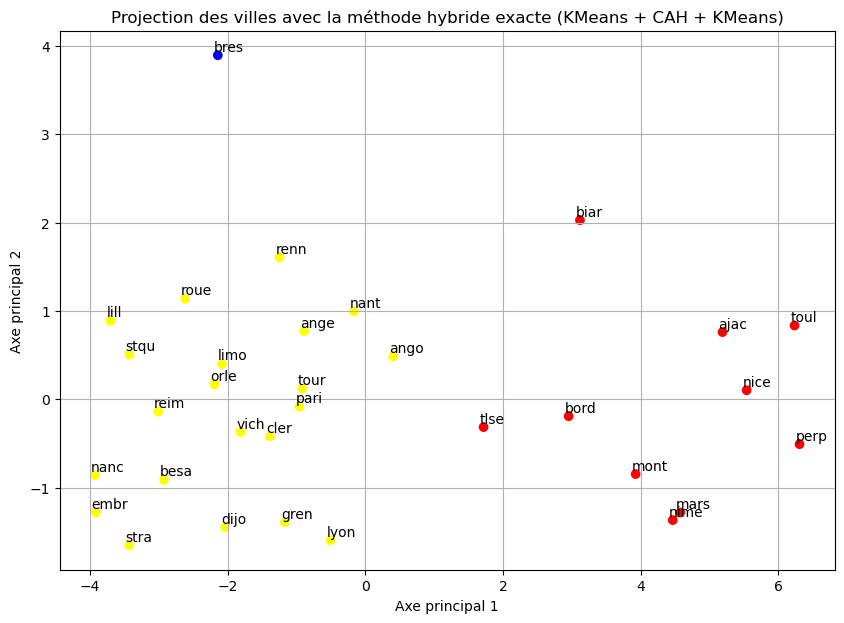

,Ville,Cluster
0,ajac,0
29,tlse,0
28,toul,0
22,perp,0
19,nime,0
18,nice,0
14,mars,0
15,mont,0
4,biar,0
5,bord,0


In [8]:
# Question 7 — Méthode hybride
# KMeans (grand K) -> CAH sur les centres -> KMeans final

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from IPython.display import display

def hybrid_clustering_prof(X, n_clusters=3, k_init=10, linkage="ward", random_state=42):
    """
    Méthode hybride exacte :
    1. KMeans avec un grand nombre de clusters (k_init)
    2. CAH sur les centres obtenus
    3. Construction de n_clusters centres finaux
    4. KMeans final initialisé avec ces centres
    """
    
    # Étape 1 : premier KMeans avec grand K
    kmeans_init = KMeans(n_clusters=k_init, random_state=random_state, n_init=10)
    labels_init = kmeans_init.fit_predict(X)
    centers_init = kmeans_init.cluster_centers_
    
    # Étape 2 : CAH sur les centres du premier KMeans
    cah = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)
    center_groups = cah.fit_predict(centers_init)
    
    # Étape 3 : construction des centres finaux
    final_centers = []
    for i in range(n_clusters):
        group_centers = centers_init[center_groups == i]
        final_center = group_centers.mean(axis=0)
        final_centers.append(final_center)
    final_centers = np.array(final_centers)
    
    # Étape 4 : KMeans final avec initialisation imposée
    kmeans_final = KMeans(
        n_clusters=n_clusters,
        init=final_centers,
        n_init=1,
        random_state=random_state
    )
    final_labels = kmeans_final.fit_predict(X)
    
    return final_labels, centers_init, center_groups, final_centers


# =========================
# Application sur villes.csv
# =========================

n_clusters = 3
k_init = 10
linkage = "ward"

hybrid_labels_prof, centers_init, center_groups, final_centers = hybrid_clustering_prof(
    X_scaled,
    n_clusters=n_clusters,
    k_init=k_init,
    linkage=linkage,
    random_state=42
)

# Score de silhouette de la méthode hybride exacte
hybrid_score_prof = silhouette_score(X_scaled, hybrid_labels_prof)

# Scores de comparaison pour k = 3
kmeans_score = silhouette_score(
    X_scaled,
    KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_scaled)
)

ward_score = silhouette_score(
    X_scaled,
    AgglomerativeClustering(n_clusters=3, linkage="ward").fit_predict(X_scaled)
)

average_score = silhouette_score(
    X_scaled,
    AgglomerativeClustering(n_clusters=3, linkage="average").fit_predict(X_scaled)
)

single_score = silhouette_score(
    X_scaled,
    AgglomerativeClustering(n_clusters=3, linkage="single").fit_predict(X_scaled)
)

print("===== Méthode hybride =====")
print(f"KMeans initial : k = {k_init}")
print(f"CAH sur les centres avec linkage = {linkage}")
print(f"KMeans final : k = {n_clusters}")
print(f"Score de silhouette (méthode hybride exacte) : {hybrid_score_prof:.4f}\n")

print("===== Comparaison avec les autres méthodes pour k = 3 =====")
print(f"KMeans                     : {kmeans_score:.4f}")
print(f"Agglomerative (ward)      : {ward_score:.4f}")
print(f"Agglomerative (average)   : {average_score:.4f}")
print(f"Agglomerative (single)    : {single_score:.4f}")
print(f"Hybride exacte du prof    : {hybrid_score_prof:.4f}")

# Visualisation dans le plan principal
colors = ['red', 'yellow', 'blue', 'pink', 'green', 'orange']

plt.figure(figsize=(10, 7))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=hybrid_labels_prof,
    cmap=matplotlib.colors.ListedColormap(colors[:n_clusters])
)

for label, x, y in zip(labels, X_pca[:, 0], X_pca[:, 1]):
    plt.annotate(label, xy=(x, y), xytext=(-3, 3), textcoords='offset points')

plt.title("Projection des villes avec la méthode hybride exacte (KMeans + CAH + KMeans)")
plt.xlabel("Axe principal 1")
plt.ylabel("Axe principal 2")
plt.grid(True)
plt.show()

# Tableau final
resultat_hybride_prof = pd.DataFrame({
    "Ville": labels,
    "Cluster": hybrid_labels_prof
})

display(resultat_hybride_prof.sort_values(by="Cluster"))

### Interprétation

La méthode hybride mise en œuvre suit l’approche présentée en cours : un premier **KMeans** est appliqué avec un nombre élevé de clusters (**k = 10**) afin d’obtenir un ensemble de centres représentatifs. Ces centres sont ensuite regroupés en **3 classes** à l’aide d’une **classification hiérarchique ascendante (CAH)** avec le critère *ward*. Enfin, ces centres servent d’initialisation à un **KMeans final**.

Dans notre cas, cette méthode obtient un score de silhouette de **0.4957** pour **k = 3 clusters**.

En comparant avec les autres méthodes :

- **KMeans** : 0.3741  
- **Agglomerative (ward)** : 0.3681  
- **Agglomerative (average)** : 0.4957  
- **Agglomerative (single)** : -0.0344  
- **Méthode hybride** : 0.4957  

On observe que la méthode hybride permet une **amélioration significative par rapport à KMeans et à la méthode hiérarchique avec le critère ward**.

Elle atteint un score **équivalent à la méthode AgglomerativeClustering avec le critère average**, qui est ici la meilleure méthode.

Cela montre que l’approche hybride permet d’obtenir une **initialisation plus pertinente**, guidant KMeans vers une partition de meilleure qualité.

D’un point de vue algorithmique, cela s’explique par le fait que :
- le premier KMeans structure les données en sous-groupes ;
- la CAH regroupe ces centres de manière plus globale ;
- le KMeans final affine ensuite cette structure.

D’un point de vue interprétatif, cela signifie que la structure des données bénéficie d’une approche en plusieurs étapes, combinant **vision globale (CAH)** et **optimisation locale (KMeans)**.

On en conclut que la méthode hybride constitue ici une **stratégie efficace**, permettant d’atteindre une qualité de clustering optimale, équivalente à la meilleure méthode testée.

Ce résultat illustre que combiner plusieurs approches peut améliorer les performances, mais aussi que certaines méthodes (comme *average*) capturent déjà efficacement la structure des données.

## Question 8 — Application de la méthode hybride sur les jeux de données `wdbc.csv` et `spamb.csv`

Dans cette question, on applique la fonction de clustering **hybride** définie précédemment sur deux nouveaux jeux de données :
- `wdbc.csv`
- `spamb.csv`

Pour chacun de ces jeux de données :
1. on charge les données ;
2. on sépare les éventuelles colonnes non numériques ou de labels ;
3. on normalise les variables ;
4. on applique la méthode hybride ;
5. on calcule l’indice de silhouette ;
6. on visualise les données projetées dans le plan principal par ACP.


Jeu de données : wdbc.csv
Dimensions du jeu de données : (568, 30)


,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,...,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
0,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
3,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
4,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,0.2087,0.07613,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440



Types de variables :
17.99     float64
10.38     float64
122.8     float64
1001      float64
0.1184    float64
dtype: object

Score de silhouette : 0.3425


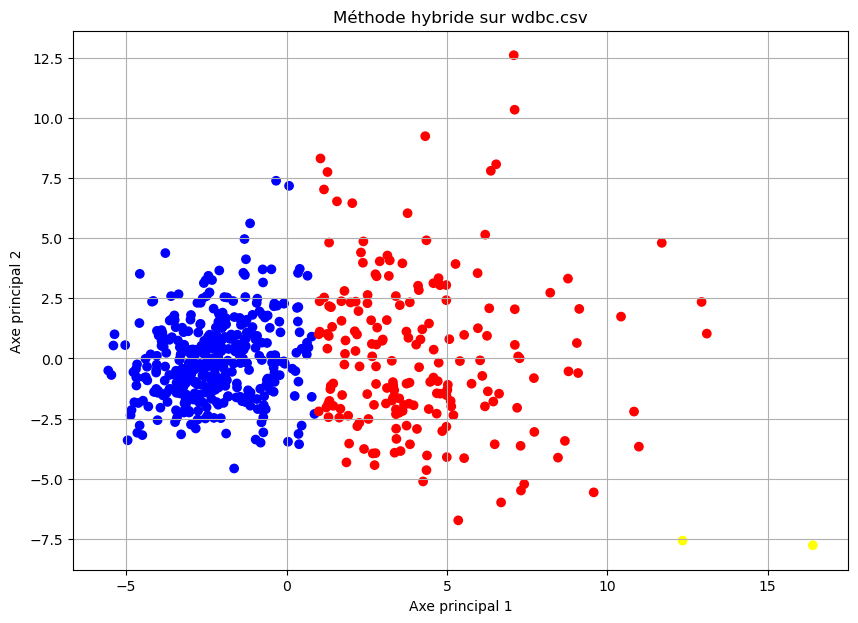


Nombre d'instances par cluster :
Cluster
0    192
1      2
2    374
Name: count, dtype: int64

Jeu de données : spamb.csv
Dimensions du jeu de données : (4600, 57)


,0,0.64,0.64.1,0.1,0.32,0.2,0.3,0.4,0.5,0.6,...,0.40,0.41,0.42,0.43,0.778,0.44,0.45,3.756,61,278
0,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028
1,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259
2,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191
4,0.00,0.00,0.00,0.0,1.85,0.00,0.00,1.85,0.00,0.00,...,0.0,0.00,0.223,0.0,0.000,0.000,0.000,3.000,15,54



Types de variables :
0         float64
0.64      float64
0.64.1    float64
0.1       float64
0.32      float64
dtype: object

Score de silhouette : 0.6737


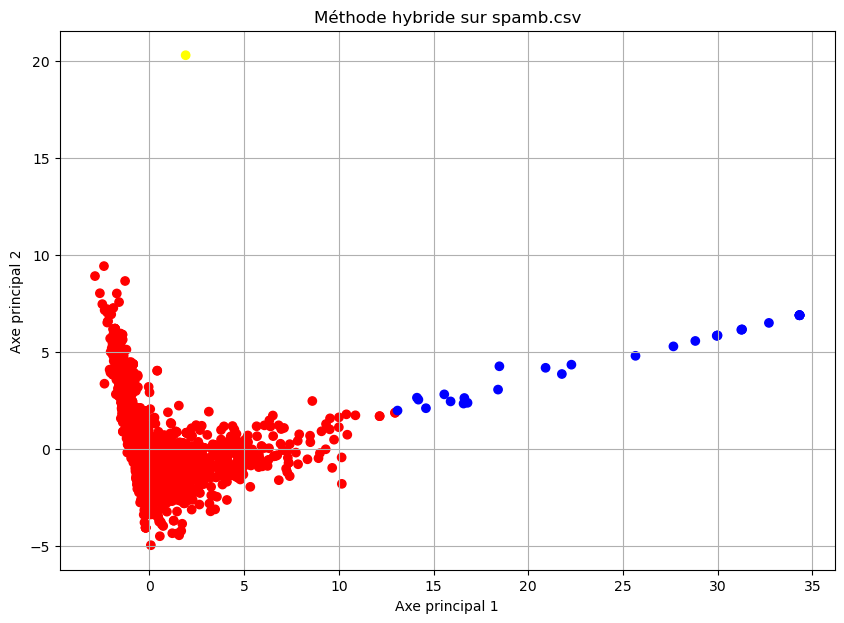


Nombre d'instances par cluster :
Cluster
0    4569
1       1
2      30
Name: count, dtype: int64


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt


def appliquer_methode_hybride(nom_fichier, sep=",", n_clusters=3, linkage='ward'):
    """
    Applique la méthode hybride exacte du prof sur un jeu de données CSV.
    """
    
    print(f"\n==============================")
    print(f"Jeu de données : {nom_fichier}")
    print(f"==============================")
    
    # Chargement du fichier
    df = pd.read_csv(nom_fichier, sep=";")
    print("Dimensions du jeu de données :", df.shape)
    display(df.head())
    
    # (BONUS PROF) Vérification des types
    print("\nTypes de variables :")
    print(df.dtypes.head())
    
    # Sélection des colonnes numériques uniquement
    X = df.select_dtypes(include=[np.number])
    
    # Vérification : si aucune colonne numérique n'est trouvée
    if X.shape[1] == 0:
        print("Erreur : aucune variable numérique détectée.")
        return
    
    # Normalisation des données
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Projection ACP pour la visualisation
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    # Application de la méthode hybride (version prof)
    hybrid_labels, _, _, _ = hybrid_clustering_prof(
        X_scaled,
        n_clusters=n_clusters,
        k_init=10,
        linkage=linkage,
        random_state=42
    )
    
    # Calcul du score de silhouette
    score = silhouette_score(X_scaled, hybrid_labels)
    print(f"\nScore de silhouette : {score:.4f}")
    
    # Visualisation des clusters
    colors = ['red', 'yellow', 'blue', 'pink', 'green', 'orange']
    
    plt.figure(figsize=(10, 7))
    plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=hybrid_labels,
        cmap=matplotlib.colors.ListedColormap(colors[:n_clusters])
    )
    
    plt.title(f"Méthode hybride sur {nom_fichier}")
    plt.xlabel("Axe principal 1")
    plt.ylabel("Axe principal 2")
    plt.grid(True)
    plt.show()
    
    # Tableau des clusters
    resultat = pd.DataFrame({
        "Cluster": hybrid_labels
    })
    
    print("\nNombre d'instances par cluster :")
    print(resultat["Cluster"].value_counts().sort_index())


# =========================
# APPLICATION
# =========================

appliquer_methode_hybride("wdbc.csv", sep=",", n_clusters=3, linkage='ward')
appliquer_methode_hybride("spamb.csv", sep=",", n_clusters=3, linkage='ward')

### Interprétation

La méthode hybride a été appliquée aux jeux de données **wdbc.csv** et **spamb.csv**, en utilisant **3 clusters**.

#### Jeu de données *wdbc.csv*

- le score de silhouette obtenu est d’environ **0.3425**, ce qui correspond à une qualité de clustering **moyenne** ;
- les clusters apparaissent relativement distincts dans le plan principal, mais avec un certain chevauchement ;
- les groupes restent globalement compacts, traduisant une cohérence interne correcte.

Cela indique que la structure des données est **présente mais peu marquée**, ce qui limite la qualité de la séparation.

#### Jeu de données *spamb.csv*

- le score de silhouette est **élevé (≈ 0.6737)**, ce qui pourrait suggérer une bonne qualité de clustering ;
- cependant, la répartition des clusters est **très déséquilibrée** (un cluster majoritaire, les autres très petits) ;
- cela signifie que le modèle isole quelques points atypiques plutôt que de structurer réellement les données.

Le score élevé est donc **à interpréter avec prudence**, car il ne reflète pas une partition équilibrée.

#### Analyse globale

On observe que la performance de la méthode hybride dépend fortement du jeu de données :

- elle donne des résultats **corrects mais limités** sur **wdbc.csv** ;
- elle produit un score élevé sur **spamb.csv**, mais avec une partition **peu pertinente**.

#### Conclusion

Ces résultats montrent que :

- la qualité d’un clustering ne doit pas être évaluée uniquement avec l’indice de silhouette ;
- il est essentiel d’analyser également la **structure et l’équilibre des clusters** ;
- la méthode hybride, bien que pertinente sur le plan méthodologique, **n’est pas systématiquement supérieure aux méthodes classiques**.

Son efficacité dépend fortement de la nature des données étudiées.